# Projects: predicting the properties of inorganic nanomaterials

Welcome to the project of the Deep Learning course!

First of all, the projects suggested here are only that, suggestions. They are for those of you who do not have an idea for a deep learning project. If you do, you are welcome to use your own data and train your own model.

Now, the project suggestions. We propose a project to do **regression** and another to do **classification**. We are going to use the [**MatBench**](https://github.com/materialsproject/matbench) benchmark datasets (Dunn, A., Wang, Q., Ganose, A., Dopp, D., & Jain, A. (2020). Benchmarking materials property prediction methods: the Matbench test set and Automatminer reference algorithm. npj Computational Materials, 6(1), 138.). We will extract them from the `matminer` library, and they are these two:

- **Matbench MP gap (Regression)**: Matbench v0.1 test dataset for predicting DFT formation energy from structure.
- **Matbench MP is metal (Classification)**: Matbench v0.1 test dataset for predicting DFT metallicity from structure.

In [1]:
# Only run this if you are on Google Colab. Otherwise, run "uv sync" on terminal to install it on your local environment
!pip install matminer

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Featurization of the data

In both cases, the dataset only has the chemical formula string (e.g. "ZnS", "GaAs", etc.), and the target value associated to it. Neural networks need numbers, not strings.

We are going to use **MAGPIE (Materials Agnostic Platform for Informatics and Exploration** features: for each element in the compound, we loop up 22 atomic properties (atomic number, electronegativity, atomic radius, etc.) and compute 6 statistics across all elements weighted by stoichiometry. This yields **132 numerical features** per composition.

This approach captures physically meaningful information.

The following code is shared for both projects. It performs the actions described in the previous paragraphs, and allows you to build the appropriate dataloaders with the

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ── Shared featurization ────────────────────────────────────────────────────

def featurize_compositions(df: pd.DataFrame,
                           composition_col: str = "composition") -> pd.DataFrame:
    """
    Convert a column of composition strings (e.g. 'ZnS') into
    132 numerical MAGPIE features.

    Returns a new DataFrame with feature columns only (no strings).
    """
    # Step 1: convert string → pymatgen Composition object
    stc = StrToComposition(target_col_id="composition_obj")
    df = stc.featurize_dataframe(df, composition_col, ignore_errors=True)

    # Step 2: compute MAGPIE features from Composition objects
    ep = ElementProperty.from_preset("magpie")
    df = ep.featurize_dataframe(df, col_id="composition_obj", ignore_errors=True)

    # Keep only the numeric feature columns
    feature_cols = ep.feature_labels()
    df = df.dropna(subset=feature_cols)   # drop any failed entries

    return df, feature_cols

# ── Shared PyTorch Dataset ──────────────────────────────────────────────────

class MaterialsDataset(Dataset):
    """
    Simple tabular dataset for materials property prediction.

    X: float32 tensor of shape (n_samples, n_features)
    y: float32 tensor of shape (n_samples, 1)
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True, drop_last=False):
    """Build train and validation DataLoaders."""
    dataset = MaterialsDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    return loader

# Classification project: metal or non-metal?

**Task**: given only the chemical formula, predict whether a compound is a metal
(band gap = 0) or a semiconductor/insulator (band gap > 0).

**Dataset**: `matbench_expt_is_metal`

## Definition of Dataset and DataLoaders

In [3]:
df_metal = load_dataset("matbench_expt_is_metal")
print(df_metal.head())
print(f"\nShape: {df_metal.shape}")
print(f"\nClass balance:\n{df_metal['is_metal'].value_counts()}")

         composition  is_metal
0           Ag(AuS)2      True
1         Ag(W3Br7)2      True
2   Ag0.5Ge1Pb1.75S4     False
3  Ag0.5Ge1Pb1.75Se4     False
4             Ag2BBr      True

Shape: (4921, 2)

Class balance:
is_metal
False    2470
True     2451
Name: count, dtype: int64


In [4]:
import os
import numpy as np

# Nombre del archivo donde guardaremos las matrices
archivo_datos = "datos_entrenamiento_metal.npz"

if os.path.exists(archivo_datos):
    # ==========================================
    # CASO 1: EL ARCHIVO EXISTE -> CARGAMOS RÁPIDO
    # ==========================================
    print("⏳ Archivo encontrado. Cargando datos desde el disco...")

    datos_cargados = np.load(archivo_datos)
    X_cls = datos_cargados["X"]
    y_cls = datos_cargados["y"]

    print(f"✅ ¡Datos cargados al instante! Dimensiones de X: {X_cls.shape}")

else:
    # ==========================================
    # CASO 2: NO EXISTE -> EJECUTAMOS TU CÓDIGO Y GUARDAMOS
    # ==========================================
    print("⚙️ Archivo no encontrado. Calculando features por primera vez (esto puede tardar)...")

    # --- TU CÓDIGO EXACTO AQUÍ ---
    df_metal, feature_cols = featurize_compositions(df_metal, composition_col="composition")

    X_cls = df_metal[feature_cols].values.astype(np.float32)
    y_cls = df_metal["is_metal"].astype(int).values.astype(np.float32)
    # -----------------------------

    print(f"📊 Feature matrix shape: {X_cls.shape}")
    print(f"⚖️ Class balance — metals: {y_cls.mean():.1%} | non-metals: {1-y_cls.mean():.1%}")

    # Guardamos las matrices generadas usando np.savez_compressed (ocupa menos espacio)
    np.savez_compressed(archivo_datos, X=X_cls, y=y_cls)
    print(f"💾 Datos guardados exitosamente en '{archivo_datos}'.")

⏳ Archivo encontrado. Cargando datos desde el disco...
✅ ¡Datos cargados al instante! Dimensiones de X: (4921, 132)


In [5]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42,
    stratify=y_cls    # preserve class balance in both splits
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, random_state=42,
    stratify=y_train_c
)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_val_c   = scaler_c.transform(X_val_c)
X_test_c  = scaler_c.transform(X_test_c)

train_loader_c = make_loader(X_train_c, y_train_c, batch_size=64, shuffle=True, drop_last=True)
val_loader_c   = make_loader(X_val_c, y_val_c, batch_size=64, shuffle=False, drop_last=False)
test_loader_c  = make_loader(X_test_c, y_test_c, batch_size=64, shuffle=False, drop_last=False)

In [6]:
print(f"Train samples: {len(train_loader_c.dataset)}")
print(f"Validation samples: {len(val_loader_c.dataset)}")
print(f"Test samples: {len(test_loader_c.dataset)}")

Train samples: 3148
Validation samples: 788
Test samples: 985


In [101]:
y_train_c


array([1., 0., 0., ..., 1., 1., 0.], shape=(3148,), dtype=float32)

## Training

The data is set up for you. From here, you will have to build a simple model to do classification, decide on a loss function and an optimizer. Advice:
- For the model: remember you have an input of 132 features and an output of a single value (in this case, the value is always between 0 and 1, since it is the probability of the input of being a metal). You can have more than a single hidden layer. Remember that between layers goes the activation function.
- For the loss function: it is a classification. That means, as stated before, that the model output has to be constrained to the range (0, 1). Look up what the [`Softmax`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Softmax.html) operation is, and see how you can include it either in the model or the loss function.

In [147]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")  # For debugging use cpu, because if it fails, CUDA gets blocked and process has to be restarted
class MetalClassifierNet(nn.Module):
    """
    Feed-forward network for binary classification.
    """

    def __init__(self, n_features: int, dropout: float = 0.3):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128, device=device)
        self.layer2 = nn.Linear(128, 64, device=device)
        self.layer3 = nn.Linear(64, 32, device=device)
        self.layer4 = nn.Linear(32, 16, device=device)
        self.layer5 = nn.Linear(16, 8, device=device)
        self.layer6 = nn.Linear(8, 2, device=device)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        x = torch.relu(x)
        x = self.layer3(x)
        x = torch.relu(x)
        x = self.layer4(x)
        x = torch.relu(x)
        x = self.layer5(x)
        x = torch.relu(x)
        x = self.layer6(x)
        x = torch.softmax(x, dim=1)
        return x



In [148]:
model_cls = MetalClassifierNet(n_features=132, dropout=0.3).to(device)
test_tensor = torch.randn(4, 132).to(device)
output = model_cls(test_tensor)
print(f"Output shape: {output.shape}")  # Should be (4, 2)
print(f"Output sample:\n{output[0]}")  # Should be a probability

import torch.optim as optim
# Adam: adaptive learning rates per parameter — usually the best default
optimizer_cls = optim.Adam(
    model_cls.parameters(),
    lr=1e-3, # Learning rate - modify this to adjust the model
    betas=(0.9, 0.999),  # decay rates for first and second moment estimates
    weight_decay=1e-5,
)

# criterion_cls = nn.BCELoss()
criterion_cls = nn.CrossEntropyLoss()
test_predictions = model_cls(test_tensor)
test_ground_truth = torch.tensor([0, 1, 0, 1], dtype=torch.long).to(device)  # Class labels for CrossEntropyLoss
test_loss = criterion_cls(test_predictions, test_ground_truth)
print(f"Test loss: {test_loss.item()}")



Output shape: torch.Size([4, 2])
Output sample:
tensor([0.5169, 0.4831], grad_fn=<SelectBackward0>)
Test loss: 0.6936817169189453


In [149]:
def train_epoch(model, loader, optimizer, criterion, device):
  model.train()
  total_loss = 0.0

  for X_batch, y_batch in loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device).squeeze().to(torch.long)

    predictions = model(X_batch)

    loss = criterion(predictions, y_batch)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss = 0.0
  with torch.no_grad():
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze().to(torch.long)

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        total_loss += loss.item()

  return total_loss / len(loader)

In [150]:
history = {"train_loss": [], "val_loss": []}

N_EPOCHS = 80
for epoch in range(N_EPOCHS):
    # Remember, for each epoch you have to perform a train_epoch and an evaluation epoch
    train_loss = train_epoch(model=model_cls, loader=train_loader_c, optimizer=optimizer_cls, criterion=criterion_cls, device=device)

    print(train_loss)

    val_loss = evaluate(model=model_cls, loader=val_loader_c, criterion=criterion_cls, device=device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

0.5193564624202495
0.4753565976814348
0.44743659240858896
0.44779275631418036
0.43899976051583584
0.4360143037474885
0.42888549760896333
0.4280974281077482
0.42958953003494105
0.42583539169661855
0.41806700339122693
0.41942224149801294
0.41839063228393086
0.4243765369969971
0.42131500402275396
0.42902732807762767
0.42534324344323604
0.4203816104908379
0.413252265477667
0.41724803070632777
0.4413393827117219
0.43608832176850765
0.4247979521751404
0.4129198923402903
0.4063411908490317
0.4130572025873223
0.4246526044242236
0.4516521868657093
0.4289157135146005
0.422585275100202
0.4213154626135923
0.4128019426550184
0.4179315871121932
0.4154696130022711
0.4091026345077826
0.3999587607627012
0.4075863726285039
0.42348036109184733
0.42583256108420237
0.4156171393637754
0.4399733373097011
0.43529109322294895
0.4296896439425799
0.42349111851380794
0.43632082428250996
0.43299836771828787
0.4450505789445371
0.44199800126406613
0.4311951885418016
0.43466958038660947
0.4374360156302549
0.434424332

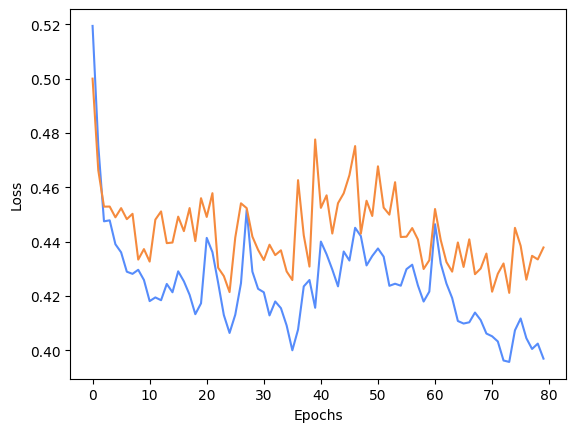

In [151]:
# Plot graphs once finished with matplotlib to see the evolution of the losses
import matplotlib.pyplot as plt
plt.figure()
plt.plot([n for n in range(N_EPOCHS)], history["train_loss"], label="Train Loss")
plt.plot([n for n in range(N_EPOCHS)], history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()